In [45]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [47]:
df = pd.read_csv("dataset.csv")

**Displaying Basic Informtion**

In [48]:
# First 5 rows
df.head()

# Last 5 rows
df.tail()

# Random 5 samples
df.sample(5)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
856,857,Karen Castillo,"SQL, Deep Learning, Python",5,MBA,Deep Learning Specialization,Data Scientist,Hire,46669,5,100
489,490,Deborah Ramirez,"SQL, Machine Learning, Deep Learning, Python",3,PhD,NaN,Data Scientist,Hire,104405,9,95
748,749,Jessica Porter,"NLP, Pytorch, TensorFlow",2,PhD,Deep Learning Specialization,AI Researcher,Reject,47573,3,60
304,305,Tina Howard,"SQL, Python, Machine Learning",6,B.Sc,AWS Certified,Data Scientist,Hire,52824,9,100
450,451,Thomas Hood,"Networking, Ethical Hacking, Cybersecurity",10,B.Sc,Google ML,Cybersecurity Analyst,Hire,92197,5,100


**Check dataset Shape**

In [49]:
df.shape      #this tells no.of rows and columns

(1000, 11)

**Droping Unnecessary columns**

In [50]:
df = df.drop(["Resume_ID", "Name", "AI Score (0-100)"], axis=1)

df.head()

,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count
0,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8
1,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1
2,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7
3,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0
4,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9


**Convert Target Variable**


convert:

1. hire-> 1
2. reject-> 0






In [51]:
df["Recruiter Decision"] = df["Recruiter Decision"].map({
    "Hire": 1,
    "Reject": 0
})

df["Recruiter Decision"].value_counts()

,count
Recruiter Decision,
1,812
0,188


**Check for Missing Values**

In [52]:
df.isnull().sum()       #if all are 0's then it is perfect

,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


**Confirm Data Types**

In [53]:
df.dtypes

,0
Skills,object
Experience (Years),int64
Education,object
Certifications,object
Job Role,object
Recruiter Decision,int64
Salary Expectation ($),int64
Projects Count,int64


**Combine Text Columns**


we combine:


1.  Skills
2.  Certifications
3.   Job Role






In [54]:
df["combined_text"] = (
    df["Skills"] + " " +
    df["Certifications"] + " " +
    df["Job Role"]
)

df[["combined_text"]].head()

,combined_text
0,NaN
1,"Deep Learning, Machine Learning, Python, SQL G..."
2,"Ethical Hacking, Cybersecurity, Linux Deep Lea..."
3,"Python, Pytorch, TensorFlow AWS Certified AI R..."
4,NaN


**Clean the Text**


We will:
1.   Convert to lowercase
2.   Remove special characters
3.   Remove extra spaces






In [55]:
import re

def clean_text(text):
    text = str(text).lower()   # <-- IMPORTANT change
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [56]:
df.isnull().sum()

,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0
combined_text,274


**Fill missing values**

In [57]:
df["Skills"] = df["Skills"].fillna("")
df["Certifications"] = df["Certifications"].fillna("")
df["Job Role"] = df["Job Role"].fillna("")

now recreate combined text

In [58]:
df["combined_text"] = (
    df["Skills"] + " " +
    df["Certifications"] + " " +
    df["Job Role"]
)

**Convert Text to Numerical Features (TF-IDF)**




In [59]:
#Import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [60]:
#Create Vectorizer
tfidf = TfidfVectorizer(max_features=500)   # max_features=500 means:We limit vocabulary to top 500 important words (helps model performance).

**Transform Text into Numbers**

In [61]:
X_text = tfidf.fit_transform(df["combined_text"])

In [62]:
X_text.shape    # output: 1000 resumes and 27 numeric features

(1000, 27)

**Extract Numeric Features**

In [63]:
numeric_features = df[[
    "Experience (Years)",
    "Salary Expectation ($)",
    "Projects Count",
    "Education"
]]

In [64]:
#check shape
numeric_features.shape

(1000, 4)

**Combine Text + Numeric**

In [65]:
# Encode Education FIRST
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Education"] = le.fit_transform(df["Education"])

# THEN create numeric_features
numeric_features = df[[
    "Experience (Years)",
    "Salary Expectation ($)",
    "Projects Count",
    "Education"
]]

In [66]:
from scipy.sparse import hstack, csr_matrix

X = hstack([X_text, csr_matrix(numeric_features.values.astype(float))])

In [67]:
numeric_features.dtypes

,0
Experience (Years),int64
Salary Expectation ($),int64
Projects Count,int64
Education,int64


In [68]:
numeric_features = numeric_features.astype(float)

In [69]:
numeric_features = df[[
    "Experience (Years)",
    "Salary Expectation ($)",
    "Projects Count",
    "Education"
]]

In [70]:
numeric_features.dtypes

,0
Experience (Years),int64
Salary Expectation ($),int64
Projects Count,int64
Education,int64


In [71]:
# now combine
from scipy.sparse import hstack

X = hstack([X_text, numeric_features])

In [72]:
X.shape

(1000, 31)

**TRAIN–TEST SPLIT**

In [73]:
from sklearn.model_selection import train_test_split

y = df["Recruiter Decision"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((800, 31), (200, 31))

**Logistic Regression**

In [74]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [75]:
model_lr = LogisticRegression(max_iter=3000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [76]:
from sklearn.metrics import accuracy_score

y_pred = model_lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.975


**Now Print Classification Report**

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95        46
           1       0.99      0.97      0.98       154

    accuracy                           0.97       200
   macro avg       0.96      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200



**Random Forest**

In [78]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))         # according to the outputs of both linear regression is performing better.

Random Forest Accuracy: 0.94


**SVM**

In [79]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear')
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.815


**KNN**

In [80]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.74


**Confusion Matrix**



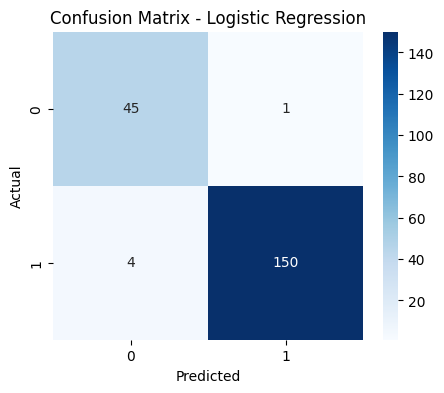

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [82]:
print(le.classes_)

['B.Sc' 'B.Tech' 'M.Tech' 'MBA' 'PhD']


**Build Hiring Prediction Function**


In [83]:
def predict_hiring(skills, experience, education, certifications, projects, salary):

    import re
    import numpy as np
    from scipy.sparse import hstack, csr_matrix

    # Combine text
    text = skills + " " + certifications

    # Clean text
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    text = clean_text(text)

    # TF-IDF transform
    text_vector = tfidf.transform([text])

    # Safe Education Encoding
    try:
        education_encoded = le.transform([education])[0]
    except:
        print("⚠️ Education not found in training data.")
        print("Available education values:", list(le.classes_))
        return

    # Numeric array
    numeric_array = np.array([[experience, salary, projects, education_encoded]])
    numeric_sparse = csr_matrix(numeric_array)

    # Combine features
    final_input = hstack([text_vector, numeric_sparse])

    # Predict
    prediction = model_lr.predict(final_input)[0]
    probability = model_lr.predict_proba(final_input)[0][1]

    result = "Hire" if prediction == 1 else "Reject"

    print("Prediction:", result)
    print("Hiring Probability:", round(probability * 100, 2), "%")

In [85]:
predict_hiring(
    skills="Python Machine Learning SQL",
    experience=3,
    education="B.Sc",
    certifications="AWS Certified",
    projects=5,
    salary=60000
)

Prediction: Hire
Hiring Probability: 98.16 %
